In [27]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

In [3]:
df = pd.read_excel("/kaggle/input/injury/Injury Severity.xlsx")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()


Shape: (53550, 24)
Columns: ['construction', 'state_x', 'city_x', 'zip_x', 'sic_code', 'date', 'fatality', 'age_x', 'sex_x', 'degree_of_inj_x', 'event_type', 'occ_code', 'event_keyword', 'abstract', 'temp', 'feels_like', 'pressure', 'humidity', 'clouds', 'visibility', 'wind_speed', 'wind_deg', 'main', 'description']


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,construction,state_x,city_x,zip_x,sic_code,date,fatality,age_x,sex_x,degree_of_inj_x,...,temp,feels_like,pressure,humidity,clouds,visibility,wind_speed,wind_deg,main,description
0,NaN,CA,LODI,95240.0,2051.0,2013-01-01,NaN,50,F,2,...,276.77,276.77,1025.0,83.0,0.0,NaN,1.14,155.0,Clear,clear sky
1,NaN,OH,CLEVELAND,44113.0,NaN,2013-01-02,X,22,F,1,...,267.59,261.95,1020.0,68.0,100.0,10000.0,4.10,220.0,Clouds,overcast clouds
2,NaN,CA,OXNARD,93030.0,2842.0,2013-01-02,NaN,29,M,2,...,286.00,283.86,1018.0,20.0,0.0,10000.0,7.72,60.0,Clear,clear sky
3,NaN,IA,CEDAR RAPIDS,52404.0,2046.0,2013-01-02,X,50,M,1,...,259.03,252.22,1023.0,82.0,0.0,NaN,3.37,191.0,Clear,clear sky
4,NaN,CA,CHATSWORTH,91311.0,2844.0,2013-01-02,NaN,30,M,3,...,284.17,282.01,1017.0,26.0,0.0,10000.0,5.70,10.0,Clear,clear sky


In [4]:
df = df[df['construction'] == 1]

In [5]:
df.isnull().sum().sort_values(ascending=False)


sic_code           8986
fatality           5780
visibility         2654
occ_code            808
event_keyword         7
city_x                2
zip_x                 0
construction          0
age_x                 0
date                  0
state_x               0
degree_of_inj_x       0
event_type            0
abstract              0
temp                  0
sex_x                 0
feels_like            0
pressure              0
humidity              0
clouds                0
wind_speed            0
wind_deg              0
main                  0
description           0
dtype: int64

In [6]:
df = df.drop_duplicates(subset=['abstract', 'event_type'])


In [7]:
df.dtypes

construction              float64
state_x                    object
city_x                     object
zip_x                     float64
sic_code                  float64
date               datetime64[ns]
fatality                   object
age_x                       int64
sex_x                      object
degree_of_inj_x             int64
event_type                  int64
occ_code                  float64
event_keyword              object
abstract                   object
temp                      float64
feels_like                float64
pressure                  float64
humidity                  float64
clouds                    float64
visibility                float64
wind_speed                float64
wind_deg                  float64
main                       object
description                object
dtype: object

In [8]:
print(df['event_type'].value_counts())


event_type
5     4265
1     1961
2     1101
14     982
13     592
6      248
12     164
4      129
8       99
7       18
3       15
10      10
9        9
11       7
Name: count, dtype: int64


In [9]:
import pandas as pd
from collections import Counter
import re

df['event_keyword'] = df['event_keyword'].astype(str).fillna('')

def clean_keywords(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text

df['clean_kw'] = df['event_keyword'].apply(clean_keywords)

def top_words_for_event_type(df, event_col='event_type', text_col='clean_kw', topN=20):
    results = {}

    for evt in sorted(df[event_col].unique()):
        subset = df[df[event_col] == evt]

        all_words = " ".join(subset[text_col].tolist()).split()
        word_counts = Counter([w for w in all_words if len(w) > 2])

        results[evt] = word_counts.most_common(topN)

    return results

top_words = top_words_for_event_type(df, topN=15)

for evt, words in top_words.items():
    print(f"\nEvent Type {evt}:")
    for w, c in words:
        print(f"   {w}: {c}")



Event Type 1:
   struck: 1602
   construction: 1077
   object: 565
   fracture: 546
   vehicle: 535
   falling: 532
   truck: 299
   crushed: 298
   over: 275
   leg: 266
   head: 258
   laceration: 241
   run: 221
   motor: 212
   installing: 203

Event Type 2:
   caught: 662
   construction: 637
   between: 363
   crushed: 325
   finger: 301
   struck: 275
   amputation: 254
   fracture: 244
   amputated: 199
   pinned: 189
   trench: 161
   vehicle: 157
   collapse: 146
   operator: 138
   truck: 132

Event Type 3:
   construction: 7
   bee: 5
   sting: 5
   allergic: 4
   reaction: 4
   infection: 3
   knee: 3
   puncture: 3
   struck: 3
   animal: 3
   bite: 3
   pipe: 2
   earthmoving: 2
   equip: 2
   shock: 2

Event Type 4:
   fall: 155
   construction: 73
   fracture: 57
   protection: 39
   tripped: 31
   struck: 30
   residential: 27
   leg: 26
   head: 25
   installing: 25
   surface: 25
   against: 24
   slip: 21
   concrete: 18
   ladder: 18

Event Type 5:
   fall: 6847


In [10]:
df['event_keyword'] = df['event_keyword'].astype(str).str.lower()

top_keywords = (
    df.groupby('event_type')['event_keyword']
      .agg(lambda x: x.value_counts().head(5).index.tolist())
)

for code, keywords in top_keywords.items():
    print(f"{code}: {keywords}")


1: ['motor vehicle,struck by', 'crushing,motor vehicle,run over,struck by', 'highway,motor vehicle,struck by', 'flagger,motor vehicle,struck by', 'struck by,vehicle']
2: ['asphyxiated,buried,collapse,trench', 'asphyxiated,caught in,trench', 'boom support cable,caught between,connecting,construction,crane,crushed,equipment operator,iron worker,metal pole,multi-employer worksite,pinned,steel beam,steel column,steel erection,torso', 'asphyxiated,crushing,trench', 'rebar,struck by,crushed']
3: ['allergic reaction,bee sting', 'loading,finger,crushed,pipe,backhoe,concrete', 'bee sting,cardiac arrest,cardiovasc system,construction,earthmoving equip,shock', 'infection,knee,puncture', 'allergic reaction']
4: ['boat,dock,drowning,underlying medical condition', 'arm,bucket ,burn,construction,face,hot asphalt,neck,plywood,projectile,spill,struck by,tripped,waterproofing', 'fall,impaled,installing,leg,lost balance,metal,rebar', 'concrete,debris,demolition,dizziness,fall on same level,fall protectio

In [11]:
text_columns = ['abstract', 'event_keyword', 'main', 'description']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna('').astype(str)



In [12]:
print("Final Shape:", df.shape)
print(df.info())


Final Shape: (9600, 25)
<class 'pandas.core.frame.DataFrame'>
Index: 9600 entries, 10 to 47180
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   construction     9600 non-null   float64       
 1   state_x          9600 non-null   object        
 2   city_x           9598 non-null   object        
 3   zip_x            9600 non-null   float64       
 4   sic_code         1072 non-null   float64       
 5   date             9600 non-null   datetime64[ns]
 6   fatality         4208 non-null   object        
 7   age_x            9600 non-null   int64         
 8   sex_x            9600 non-null   object        
 9   degree_of_inj_x  9600 non-null   int64         
 10  event_type       9600 non-null   int64         
 11  occ_code         8881 non-null   float64       
 12  event_keyword    9600 non-null   object        
 13  abstract         9600 non-null   object        
 14  temp             96

In [13]:
import re

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-z\s]', '', t)
    t = re.sub(r'\s+', ' ', t)
    return t.strip()
df['text'] = (df['abstract'].fillna('') + ' ' +
              df['event_keyword'].fillna('') )

In [14]:
merge_map = {
    0: "Other/Unclassified",
    1: "Struck by/against",
    2: "Caught/Equipment",
    3: "Other/Animal",
    4: "Falls",
    5: "Falls",
    6: "Struck by/against",
    7: "Caught/Equipment",
    8: "Chemical/Exposure",
    9: "Chemical/Exposure",
    10: "Chemical/Exposure",
    11: "Medical/Illness",
    12: "Medical/Illness",
    13: "Electrical",
    14: "Fire/Explosion"
}
cleaned_df = df.copy()
cleaned_df['merged_event'] = cleaned_df['event_type'].map(merge_map)


In [15]:
cleaned_df_train = cleaned_df[['event_type', 'text','event_keyword','abstract','temp','pressure','humidity','wind_speed','wind_deg','merged_event']]


In [16]:
print("New merged category counts:\n")
print(cleaned_df['merged_event'].value_counts())

New merged category counts:

merged_event
Falls                4394
Struck by/against    2209
Caught/Equipment     1119
Fire/Explosion        982
Electrical            592
Medical/Illness       171
Chemical/Exposure     118
Other/Animal           15
Name: count, dtype: int64


In [17]:
cleaned_df.info()
cleaned_df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 9600 entries, 10 to 47180
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   construction     9600 non-null   float64       
 1   state_x          9600 non-null   object        
 2   city_x           9598 non-null   object        
 3   zip_x            9600 non-null   float64       
 4   sic_code         1072 non-null   float64       
 5   date             9600 non-null   datetime64[ns]
 6   fatality         4208 non-null   object        
 7   age_x            9600 non-null   int64         
 8   sex_x            9600 non-null   object        
 9   degree_of_inj_x  9600 non-null   int64         
 10  event_type       9600 non-null   int64         
 11  occ_code         8881 non-null   float64       
 12  event_keyword    9600 non-null   object        
 13  abstract         9600 non-null   object        
 14  temp             9600 non-null   float64   

,construction,zip_x,sic_code,date,age_x,degree_of_inj_x,event_type,occ_code,temp,feels_like,pressure,humidity,clouds,visibility,wind_speed,wind_deg
count,9600.0,9600.000000,1072.000000,9600,9600.000000,9600.000000,9600.000000,8881.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,7175.000000,9600.000000,9600.000000
mean,1.0,59936.450729,1737.714552,2017-09-01 10:37:12.000000256,41.289271,1.632292,5.429688,1598.285779,291.501445,291.057509,1016.978021,60.769167,41.037813,9688.621463,3.735348,178.681458
min,1.0,603.000000,1081.000000,2013-01-02 00:00:00,12.000000,1.000000,1.000000,0.000000,240.570000,233.570000,967.000000,1.000000,0.000000,201.000000,0.000000,0.000000
25%,1.0,32821.750000,1611.000000,2016-08-25 00:00:00,30.000000,1.000000,2.000000,575.000000,285.297500,284.130000,1013.000000,46.000000,0.000000,10000.000000,2.100000,81.000000
50%,1.0,67021.000000,1731.000000,2018-01-22 00:00:00,40.000000,2.000000,5.000000,707.000000,292.820000,292.430000,1017.000000,62.000000,32.000000,10000.000000,3.470000,190.000000
75%,1.0,91632.000000,1761.000000,2019-02-14 00:00:00,51.000000,2.000000,5.000000,889.000000,299.060000,299.230000,1021.000000,77.000000,75.000000,10000.000000,5.140000,270.000000
max,1.0,99835.000000,8741.000000,2021-07-26 00:00:00,99.000000,3.000000,14.000000,9991.000000,319.310000,321.550000,1044.000000,100.000000,100.000000,10000.000000,17.990000,360.000000
std,0.0,30751.609888,537.305075,NaN,13.023766,0.598814,4.171355,2270.566152,9.991165,11.764591,6.303340,21.026983,40.529961,1359.499036,2.410643,110.281360


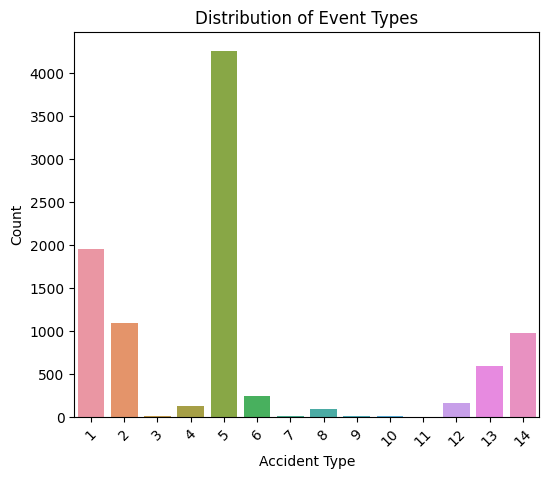

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='event_type', data=cleaned_df)
plt.title('Distribution of Event Types')
plt.xlabel('Accident Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


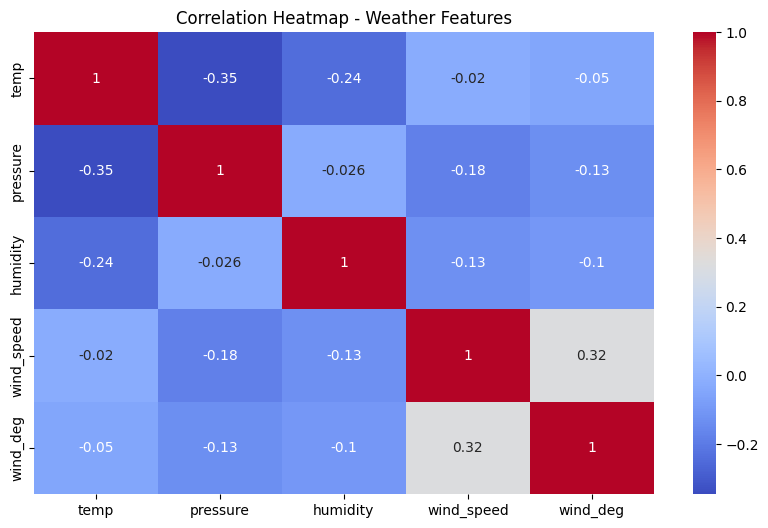

In [19]:
numeric_cols = ['temp','pressure','humidity',
                'wind_speed','wind_deg']

plt.figure(figsize=(10,6))
sns.heatmap(cleaned_df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Weather Features')
plt.show()


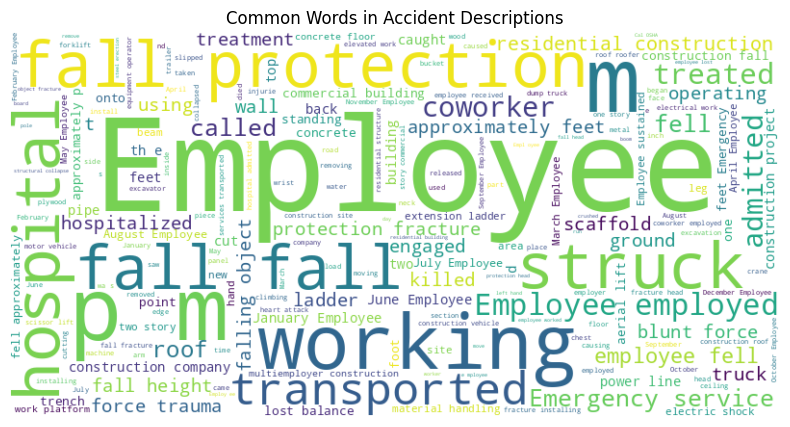

In [20]:
from wordcloud import WordCloud

text = ' '.join(cleaned_df['text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Accident Descriptions')
plt.show()


In [22]:
model = SentenceTransformer('all-mpnet-base-v2', device='cuda')


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [23]:
text_embeddings = model.encode(cleaned_df['text'].tolist(), show_progress_bar=True)


Batches:   0%|          | 0/300 [00:00<?, ?it/s]

In [24]:
le = LabelEncoder()
y = le.fit_transform(cleaned_df_train['merged_event'])


In [28]:


numeric_cols = ['temp','pressure','humidity','wind_speed','wind_deg']
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(cleaned_df[numeric_cols])
X = text_embeddings

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
from sklearn.utils.class_weight import compute_class_weight


classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=y_train)
class_weights = dict(zip(classes, weights))

sample_weights = np.array([class_weights[y] for y in y_train])

clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=10,
    random_state=42,
    eval_metric="mlogloss",
    device='cuda'
)
clf.fit(X_train, y_train, sample_weight=sample_weights)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [20:12:59] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


Classification Report (Merged Categories):

                   precision    recall  f1-score   support

 Caught/Equipment       0.71      0.68      0.70       224
Chemical/Exposure       0.74      0.71      0.72        24
       Electrical       0.79      0.93      0.85       118
            Falls       0.95      0.95      0.95       879
   Fire/Explosion       0.69      0.54      0.61       196
  Medical/Illness       0.58      0.62      0.60        34
     Other/Animal       0.25      0.33      0.29         3
Struck by/against       0.76      0.81      0.78       442

         accuracy                           0.83      1920
        macro avg       0.68      0.70      0.69      1920
     weighted avg       0.83      0.83      0.83      1920



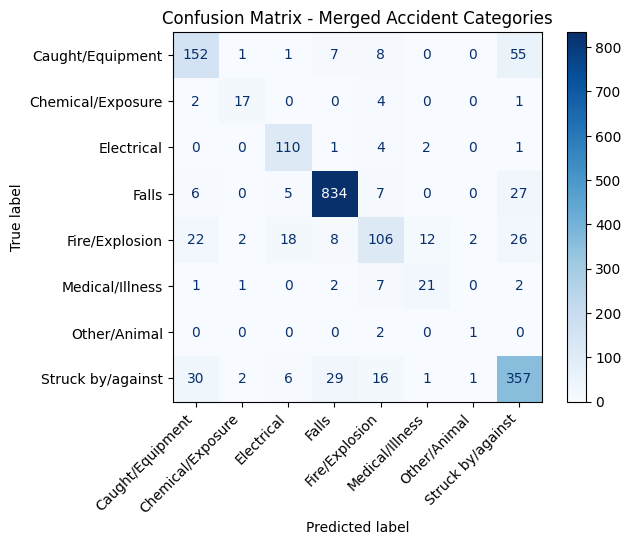

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

print("Classification Report (Merged Categories):\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.title("Confusion Matrix - Merged Accident Categories")
plt.show()


In [ ]:
import joblib

joblib.dump(clf, "/kaggle/working/risk_xgb_model.pkl")
joblib.dump(le, "/kaggle/working/label_encoder.pkl")
joblib.dump(scaler, "/kaggle/working/numeric_scaler.pkl")



In [32]:
safety_recommendations = {
    "Falls": [
        "Install guardrails",
        "Ensure fall arrest systems are in place",
        "Use proper PPE (harnesses, lanyards)",
        "Conduct fall protection training",
        "Perform hazard assessments before working at height"
    ],
    "Struck by/against": [
        "Ensure exclusion zones are established",
        "Wear high-visibility PPE",
        "Use spotters for lifting operations",
        "Ensure equipment is properly maintained and inspected",
        "Ensure workers are trained to recognize hazards"
    ],
    "Caught/Equipment": [
        "Implement lockout/tagout procedures",
        "Ensure machine guards are in place",
        "Provide proper training on equipment safety",
        "Perform regular equipment inspections",
        "Establish safe work zones around moving equipment"
    ],
    "Fire/Explosion": [
        "Ensure fire extinguishers are readily available",
        "Establish fire watch for hot work",
        "Provide fire-resistant PPE",
        "Conduct fire drills and emergency response training",
        "Inspect and maintain electrical wiring to prevent fire hazards"
    ],
    "Electrical": [
        "Ensure all electrical systems are de-energized before work",
        "Use insulated tools and proper PPE",
        "Implement lockout/tagout procedures",
        "Ensure workers are trained in electrical safety",
        "Regularly inspect electrical equipment for wear and tear"
    ],
    "Medical/Illness": [
        "Ensure first aid kits are easily accessible",
        "Train employees in basic first aid and CPR",
        "Establish a clear reporting system for medical emergencies",
        "Ensure access to healthcare providers during working hours",
        "Promote ergonomics to prevent medical issues"
    ],
    "Chemical/Exposure": [
        "Use proper ventilation systems",
        "Ensure all chemicals are clearly labeled",
        "Provide appropriate PPE (gloves, masks, etc.)",
        "Ensure access to safety data sheets (SDS) for all chemicals",
        "Implement spill containment and cleanup procedures"
    ],
    "Other/Animal": [
        "Ensure workers are trained on animal handling",
        "Use protective barriers around animals",
        "Ensure safe storage of animal-related tools and chemicals",
        "Have an emergency plan for animal-related incidents"
    ]
}
def recommend_safety_actions(event_type):
    recommended_actions = []
    description = description.lower()
    
    if "fall" in event_type:
        event_type = "Falls"
    elif "struck" in event_type or "against" in event_type:
        event_type = "Struck by/against"
    elif "caught" in event_type or "equipment" in event_type:
        event_type = "Caught/Equipment"
    elif "fire" in event_type or "explosion" in event_type:
        event_type = "Fire/Explosion"
    elif "electrical" in event_type:
        event_type = "Electrical"
    elif "medical" in event_type or "illness" in event_type:
        event_type = "Medical/Illness"
    elif "chemical" in event_type or "exposure" in event_type:
        event_type = "Chemical/Exposure"
    elif "animal" in event_type or "other" in event_type:
        event_type = "Other/Animal"
    else:
        event_type = "General" 
    
    if event_type in safety_recommendations:
        recommended_actions.extend(safety_recommendations[event_type])
    
    if not recommended_actions:
        recommended_actions.append("General safety precautions apply.")
    
    return recommended_actions


In [33]:
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os
import re

class WorkSafetyEvidence:
    def __init__(self):
        self.model = SentenceTransformer('all-mpnet-base-v2')
        self.data = None
        self.embeddings = None
        self.merge_map = {
                            0: "Other/Unclassified",
                            1: "Struck by/against",
                            2: "Caught/Equipment",
                            3: "Other/Animal",
                            4: "Falls",
                            5: "Falls",
                            6: "Struck by/against",
                            7: "Caught/Equipment",
                            8: "Chemical/Exposure",
                            9: "Chemical/Exposure",
                            10: "Chemical/Exposure",
                            11: "Medical/Illness",
                            12: "Medical/Illness",
                            13: "Electrical",
                            14: "Fire/Explosion"
                        }

    def clean_text(self, t):
        t = str(t).lower()
        t = re.sub(r'[^a-z\s]', '', t)
        t = re.sub(r'\s+', ' ', t)
        return t.strip()

    def load_data(self, file_path):
        print("Loading historical accident data...")
        df = cleaned_df
   
        df['text_for_bert'] = df['text']
        essential_columns = [
            'text_for_bert', 'abstract', 'event_type', 'degree_of_inj_x',
            'event_keyword', 'merged_event','state_x'
        ]
        self.data = df[essential_columns]

        print(f"Loaded {len(self.data)} past accidents")
        print("Category distribution:")
        print(self.data['merged_event'].value_counts())
        return self.data

    def create_embeddings(self):
        print("Creating embeddings from accident data...")
        texts = self.data['text_for_bert'].tolist()
        self.embeddings = self.model.encode(texts, show_progress_bar=True)
        print("Accident embeddings ready!")
        return self.embeddings

    def save_system(self, save_folder="/kaggle/working/safety_system"):
        if not os.path.exists(save_folder):
            os.makedirs(save_folder)

        with open(f'{save_folder}/embeddings.pkl', 'wb') as f:
            pickle.dump(self.embeddings, f)

        essential_columns = ['abstract', 'event_type', 'degree_of_inj_x', 'merged_event', 'event_keyword']
        essential_data = self.data[essential_columns]
        essential_data.to_pickle(f'{save_folder}/accident_data.pkl')

        print(f"System saved to '{save_folder}' folder!")

    def load_system(self, save_folder="safety_system"):
        try:
            with open(f'{save_folder}/embeddings.pkl', 'rb') as f:
                self.embeddings = pickle.load(f)

            self.data = pd.read_pickle(f'{save_folder}/accident_data.pkl')

            print(f"System loaded from '{save_folder}'!")
            print(f"{len(self.data)} incidents ready")
            return True
        except FileNotFoundError:
            print("No saved system found. Please create embeddings first.")
            return False

    def find_similar_accidents(self, planned_work, top_k=5):
        if self.embeddings is None:
            return "Please create embeddings first!"

        clean_query = self.clean_text(planned_work)
        work_embedding = self.model.encode([clean_query])
        similarities = cosine_similarity(work_embedding, self.embeddings)[0]
        top_indices = np.argsort(similarities)[-top_k:][::-1]

        evidence = []
        for idx in top_indices:
            accident = self.data.iloc[idx]
            evidence.append({
                'similarity': round(similarities[idx], 3),
                'past_accident': accident['abstract'],
                'accident_type': accident.get('event_type', 'N/A'),
                'event_category': accident.get('merged_event', 'N/A'),
                'severity': accident.get('degree_of_inj_x', 'N/A'),
                'keywords': accident.get('event_keyword', ''),
                'state': accident.get('state_x')
            })
        return evidence

In [34]:
def setup_system():
    safety_system = WorkSafetyEvidence()
    safety_system.load_data("/kaggle/input/injury/Injury Severity.xlsx")
    safety_system.create_embeddings()
    safety_system.save_system()
    return safety_system

safety_system = setup_system()
print("One-time setup complete! Now use fast loading.")

Loading historical accident data...
Loaded 9600 past accidents
Category distribution:
merged_event
Falls                4394
Struck by/against    2209
Caught/Equipment     1119
Fire/Explosion        982
Electrical            592
Medical/Illness       171
Chemical/Exposure     118
Other/Animal           15
Name: count, dtype: int64
Creating embeddings from accident data...


Batches:   0%|          | 0/300 [00:00<?, ?it/s]

Accident embeddings ready!
System saved to '/kaggle/working/safety_system' folder!
One-time setup complete! Now use fast loading.


In [35]:
def load_system_fast():
    safety_system = WorkSafetyEvidence()
    if safety_system.load_system():
        print("System ready for instant queries!")
        return safety_system
    else:
        return None

system = load_system_fast()

System loaded from 'safety_system'!
9600 incidents ready
System ready for instant queries!


In [36]:
test_query = "The crew will install prefabricated steel roof trusses on the third level of the commercial building. Two mobile cranes and chain hoists will be used to lift materials into position. Workers will secure the trusses using impact wrenches and welding torches while standing on temporary scaffolds and roof beams. The operation is scheduled for late afternoon when wind speeds typically increase. Fall-protection harnesses and guardrails have been provided, but footing is expected to be slippery due to residual moisture from morning rain"

if system:
    print(f"Testing with construction safety query...")

    results = system.find_similar_accidents(test_query, top_k=3)

    for i, result in enumerate(results, 1):
        print(f"{i}. Similarity Score: {result['similarity']}")
        print(f"   Event Category: {result['event_category']}")
        print(f"   Accident Type: {result['accident_type']}")
        print(f"   Severity Level: {result['severity']}")
        print(f"   Keywords: {result['keywords']}")
        print(f"   Past Accident Summary: {result['past_accident'][:200]}...")
        print(f"   State: {result['state']}")
        print("-" * 80)
        
else:
    print("System not loaded. Please run one-time setup first.")

Testing with construction safety query...
1. Similarity Score: 0.6660000085830688
   Event Category: Falls
   Accident Type: 5
   Severity Level: 2
   Keywords: fall,fall protection,falling object,fracture,head,installing,rib,roof,roofer,truss
   Past Accident Summary: At 4:30 p.m. on February 5, 2019, two employees (Employee #1 and Employee #2) wo rked to install trusses when, while guiding a truss being lowered into place, th e truss the employees were attached to...
   State: None
--------------------------------------------------------------------------------
2. Similarity Score: 0.652999997138977
   Event Category: Falls
   Accident Type: 5
   Severity Level: 2
   Keywords: crane,fall protection,falling object,roof,truss
   Past Accident Summary: At 1:15 p.m. on March 9, 2017, an employee was helping set roof trusses packs on to the roof structure. The employee fell while performing signaling operation fo r crane operation  and was injured....
   State: None
----------------------

# Fine tuning Bert


In [ ]:
!pip install transformers datasets accelerate

In [37]:
le = LabelEncoder()
df["label"] = le.fit_transform(cleaned_df["merged_event"])

texts = df["text"].tolist()
labels = df["label"].tolist()

num_labels = len(le.classes_)
print("Labels:", le.classes_)
print("Num labels:", num_labels)


Labels: ['Caught/Equipment' 'Chemical/Exposure' 'Electrical' 'Falls'
 'Fire/Explosion' 'Medical/Illness' 'Other/Animal' 'Struck by/against']
Num labels: 8


In [38]:
from transformers import DistilBertTokenizerFast

train_texts, test_texts, train_labels, test_labels =    train_test_split(texts, labels, test_size=0.2,
                     random_state=42, stratify=labels)


tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=256)



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [39]:
import torch

class InjuryDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = InjuryDataset(train_encodings, train_labels)
test_dataset  = InjuryDataset(test_encodings, test_labels)


In [ ]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/content/bert_finetuned",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none"
)


In [ ]:
!pip install evaluate


In [ ]:
import evaluate
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    return {
        "macro_f1": macro_f1,
        "accuracy": accuracy
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()
print(trainer.evaluate())
from sklearn.metrics import classification_report

pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=1)

print(classification_report(test_labels, y_pred, target_names=le.classes_))


In [ ]:
model.save_pretrained("/kaggle/working/distilbert_model")
tokenizer.save_pretrained("/kaggle/working/distilbert_model")


In [ ]:
import zipfile
import os

# Path to the directory you want to zip
folder_to_zip = '/kaggle/working/distilbert_model'

# Create a zip file
with zipfile.ZipFile('distilbert_model.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_to_zip):
        for file in files:
            # Create the full path to the file
            full_file_path = os.path.join(root, file)
            # Add the file to the zip file
            zipf.write(full_file_path, arcname=os.path.relpath(full_file_path, folder_to_zip))

print("Directory zipped successfully.")